---
title: Box Plots
subtitle: "DS 2023 | Communicating with Data"
---

## Overview

:::{image}images/box_plot.png
:width: 500px
:align: left
:::

A box plot is a way to display the summary statistics of a numeric feature.

It uses a minimalist geometric drawing composed of a set of glyphs &mdash; a rectangle (the "box"), perpendicular lines (the "whiskers"), and small circles &mdash; plotted along a line. 

The line is metric, such that distance maps onto a numeric scale, and the position of the glyphps along the axis signifies their numeric values.

Because of its design, box plots are often called "box-and-whiskers" plots.

Using the symbolism of the image, a box plot represents the following statistics:

:::{table}
| Statistic | Location on box plot |
| --- | --- |
| Minimum value (min) | Far left whisker |
| First quartile (Q1) | Far left box border |
| Median value | Central line |
| Third quartile (Q3) | Far right box border |
| Maximum value (max) | Far right whisker |
| Interquartile range (IQR) | The box |
| Outliers | Dots to the left and right of Q1 and Q3 |
:::

<!-- - Minimum value (min): far left whisker
- First quartile (Q1): far left box border
- Median value: central line
- Third quartile (Q3): far right box border
- Maximum value (max): far right whishker
- Interquartile range (IQR): the box
- Outliers: dots to the left and right of Q1 and Q3 -->

:::{note}
An early version of the box plot, called a "range bar," was invented by [Mary Eleanor Spear](https://en.wikipedia.org/wiki/Mary_Eleanor_Spear).  

![](images/range-bar.png)<br/>
From _Charting Statistics_, 1952, p. 166.

Spear's idea was later developed by John Tukey in 1975 into the box plots we see today. Tukey added the whiskers, which represents his formula for defining outliers.

:::

## Use Cases

Box plots play a central role in exploratory data analysis (EDA).

The can quickly show how much a distribution varies from the normal.

They are also optimized for showing **outliers** &mdash; in fact, the minumum and maximum values represented by the outer whiskers are estimates of outlier thresholds.

## How outliers are computed

Each of the visual features of the box plot corresponds to a number based on the **quantiles** associated with a series. The order of computation is as follows:

1. Compute $Q1$, the median, and $Q3$, i.e. the first, second, and third quantiles.
   - These values may be computed by hand but are easily obtained by tools like Pandas' `.quartile()` and `.median()` methods.
3. Compute the interquartile range $IQR$:
    - $IQR = Q3 - Q1$.
4. Multiply the $IQR$ by a factor, which is usually $1.5$ by Tukey's rule:
   - $tukey = IQR \times 1.5$
5. Compute the $max$ and $min$ values:
   - $min = Q1 - tukey$
   - $max = Q3 + tukey$
   - Replace these values with the nearest actual data points that do not exceed the value. 

6. Find outliers:
   - $< min$
   - $> max$

:::{note}
The use of value of $1.5$ in the formulas to compute $min$ and $max$ is called Tukey's rule. Tukey settled on this number as a sweet spot based on the standard deviation of a normal distribution. For a deep-dive into this topics, see [Lin, Zhang, and Tong, 2024, _When Tukey Meets Chauvenet: A New Boxplot Criterion for Outlier Detection_](https://www.tandfonline.com/doi/full/10.1080/10618600.2025.2520577).
:::

## Creating a box plot from scratch

First, let's create a function to compute the various stats required to construct a box plot from a series of numeric data.

In [297]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_box_stats(S):
    Q1, Q2, Q3 = S.quantile([.25, .5, .75])
    IQR = Q3 - Q1
    tukey = IQR * 1.5
    box_min = Q1 - tukey
    box_max = Q3 + tukey
    box_min_adj = S[S >= box_min].min() # Find nearest actually data point
    box_max_adj = S[S <= box_max].max() # ditto
    outliers = S[(S < box_min) | (S > box_max)].to_list()
    return {
        'Q1': Q1, 
        'mean' : Q2, 
        'Q3': Q3, 
        'IQR': IQR,
        'min': box_min_adj, 
        'max': box_max_adj, 
        'outliers': outliers
    }

Let's try it out on the tips data set.

In [298]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [299]:
tips_stats = compute_box_stats(tips.total_bill)
tips_stats

{'Q1': 13.3475,
 'mean': 17.795,
 'Q3': 24.127499999999998,
 'IQR': 10.779999999999998,
 'min': np.float64(3.07),
 'max': np.float64(40.17),
 'outliers': [48.27, 44.3, 41.19, 48.17, 50.81, 45.35, 40.55, 43.11, 48.33]}

Now let's create a function to draw the box plot.

We will use straight matplotlib here, i.e. the functions `plt.subplots()` and `plt.plot()`.

:::{note}

The `plt.plot()` function just takes a list of x values as its first argument and y values as its second and plots them.

This is the function that Pandas `df.plot()` uses.

:::

In [306]:
def box_plot(box_stats, color='gray'):

    fig, ax = plt.subplots(figsize=(10, 1))

    # Draw the horizontal lines
    plt.plot([box_stats['min'], box_stats['Q1']], [1, 1], c=color)
    plt.plot([box_stats['Q3'], box_stats['max']], [1, 1], c=color)

    # Draw the vertical lines
    for k in ['min', 'Q1', 'mean', 'Q3', 'max']:
        x = box_stats[k]
        plt.plot([x, x], [.95, 1.05], c=color)

    # Draw the box top and bottom
    plt.plot([box_stats['Q1'], box_stats['Q3']], [.95, .95], c=color)
    plt.plot([box_stats['Q1'], box_stats['Q3']], [1.05, 1.05], c=color)

    # Draw the outliers
    for ol in box_stats['outliers']: 
        plt.plot(ol, 1, c=color, marker='x', alpha=.75)

    # Clean up
    sns.despine(left=True, bottom=True)
    plt.yticks([])
    
    plt.show()

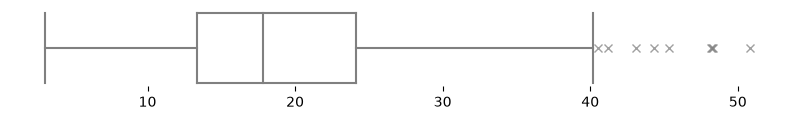

In [303]:
box_plot(tips_stats)

## Using Pandas' box plot function

Of course, Pandas can do all this for you and more.

Here is the simplest example.

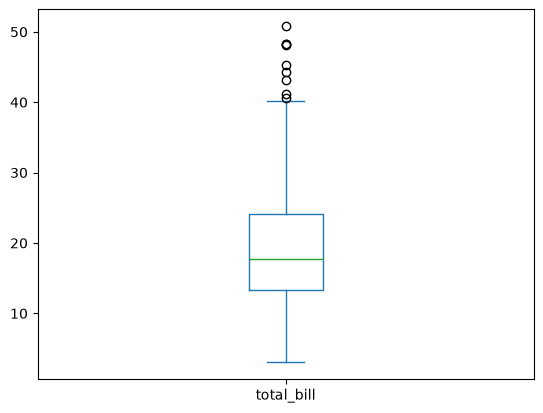

In [307]:
tips.total_bill.plot.box()
plt.show()

We can make the plot horizontal by seting `vert` to `False`.

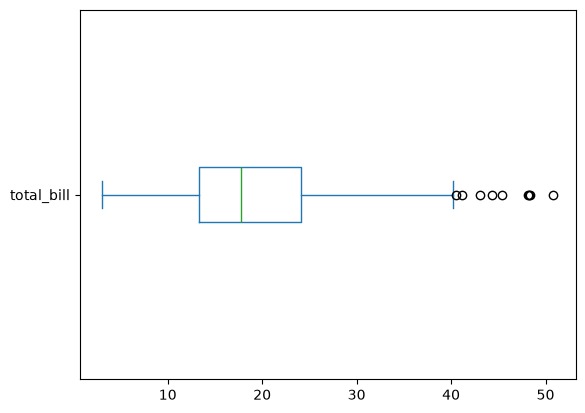

In [285]:
tips.total_bill.plot.box(vert=False)
plt.show()

We are of course also free to clean it up a bit. A single box plot doesn't really need a bounding box.


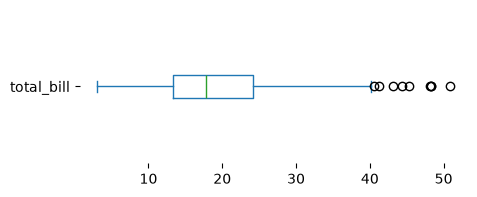

In [309]:
tips.total_bill.plot.box(vert=False, figsize=(5, 2))
sns.despine(left=True, bottom=True)
plt.show()

## Showing box plots by category

Let's look at another data set to show how box plots for multiple series can be plotted on the same axes.

Here we use the `healthexp` data set from Seaborn which tracks health costs and outcomes for various countries from $1970$ to $2022$.

In [310]:
healthexp = sns.load_dataset('healthexp')
healthexp.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


To plot all of these at once, in order to compare them, we can set the `by` parameter to `Country`.

This implicitly groups the data by `Country` and then shows the respective box plots on a single axes.

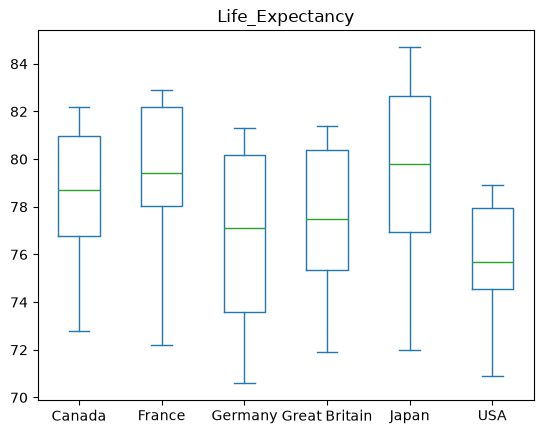

In [311]:
healthexp.plot.box(column="Life_Expectancy", by="Country")
plt.show()

:::{caution}

The `by` argument in Pandas' `.plot.box()` works differently than it does in `.plot.hist()`, even though they should probably work the same way. If used with narrow data in a box plot, Pandas will produce subplots. 

A good practice is to work with wide data when you want to plot multiple series on the same axes. 

:::

Here is how we can achieve the same effect using wide data.

In [312]:
life_exp_wide = healthexp.pivot(index='Year', columns='Country', values='Life_Expectancy')
life_exp_wide.head()

Country,Canada,France,Germany,Great Britain,Japan,USA
Year,,,,,,
1970,NaN,72.2,70.6,71.9,72.0,70.9
1971,72.8,NaN,70.8,71.9,72.9,71.2
1972,NaN,NaN,71.0,NaN,73.2,71.2
1973,NaN,NaN,71.3,NaN,73.4,71.4
1974,NaN,NaN,71.5,NaN,73.7,72.0


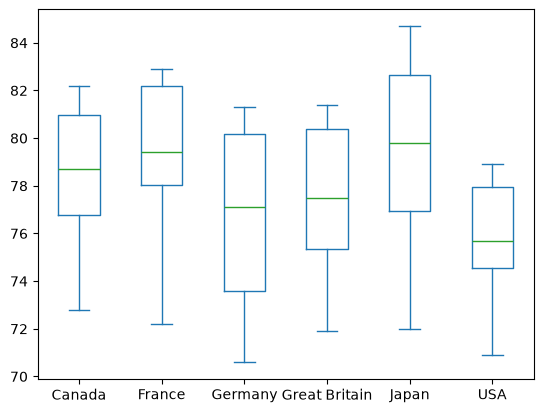

In [313]:
life_exp_wide.plot.box()
plt.show()

A horizontal view is sometimes preferable when the number of box plots is large, given the constraint of page width.

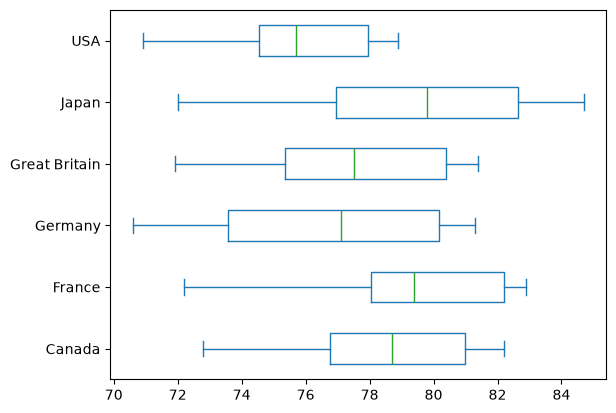

In [315]:
life_exp_wide.plot.box(vert=False)
plt.show()

Now, we _can_ use subplots to compare the categories, but since box plots are relatively compact, there is no real value gained by doing this.

In fact, it complicates things. You have to remove things to make the visualization clearer.

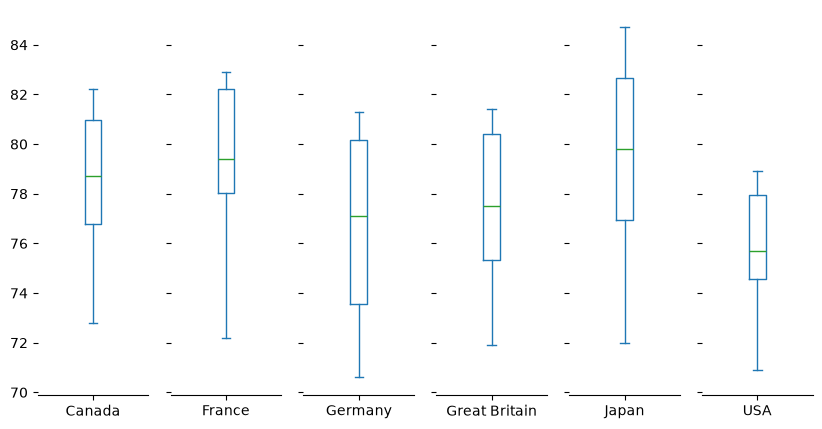

In [316]:
life_exp_wide.plot.box(subplots=True, figsize=(10,5), sharey=True)
sns.despine(left=True)
plt.show()

## Sorting by median

Often, it is useful to sort the box plots to show ranking. It is common practice to sort by median.

Here is a way to do that.

In [323]:
life_exp_wide.median().sort_values().index

Index(['USA', 'Germany', 'Great Britain', 'Canada', 'France', 'Japan'], dtype='str', name='Country')

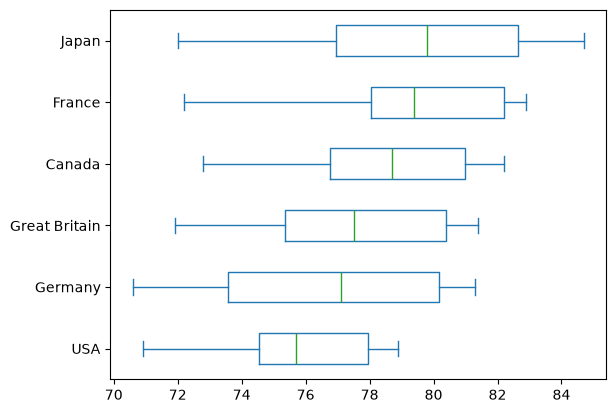

In [324]:
life_exp_wide[life_exp_wide.median().sort_values().index].plot.box(vert=False)
plt.show()

## Sorting by category

Sometimes, the categories used to group box plots have a natural order.

This is true of the `day` feature in the `tips` data set.

You want these to display in order.

But look what happens when you ask Pandas' to group the plots by `day`.

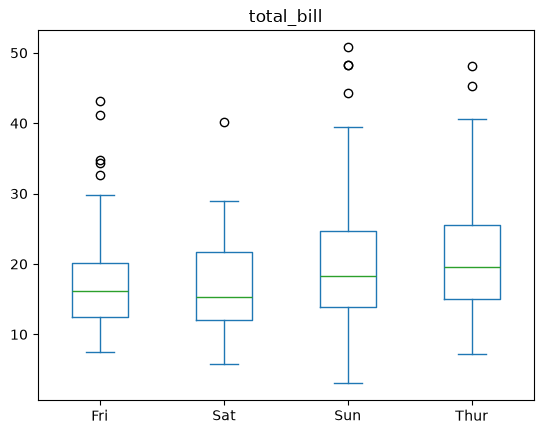

In [327]:
tips.plot.box(column='total_bill', by='day')
plt.show()

They display out of their natural order; instead, they are displayed in alphabetic order, which is not what we want.

This happens even though the data type associated with `day` in `tips` is `Category`, which preserves the correct order. Howber, the plot function does not honor this order.

The solution to this is to create a wide version of the data, i.e. we need to project the domain of `day` onto the column axis of a new data frame.

In [329]:
tip_groups = tips.groupby('day')
tips_wide = pd.concat([g[1].total_bill for g in tip_groups], axis=1, keys=[g[0] for g in tip_groups])
tips_wide.sort_index()

,Thur,Fri,Sat,Sun
0,NaN,NaN,NaN,16.99
1,NaN,NaN,NaN,10.34
2,NaN,NaN,NaN,21.01
3,NaN,NaN,NaN,23.68
4,NaN,NaN,NaN,24.59
...,...,...,...,...
239,NaN,NaN,29.03,NaN
240,NaN,NaN,27.18,NaN
241,NaN,NaN,22.67,NaN
242,NaN,NaN,17.82,NaN


Note the order of the days that order of days is what we want.

Now, we can pass the wide table to Pandas and it will do the right thing.

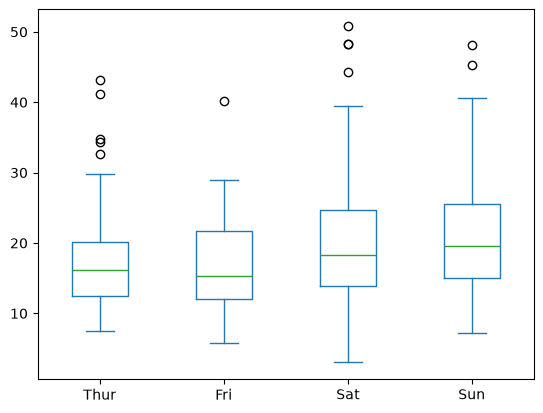

In [330]:
tips_wide.plot.box()
plt.show()

## Change the properties of the box plot image

There are various properties of box plots that can be changed by passing values to the `boxprops` dictionary.

As always, consult the documentation to learn about all the properties that can be changed.

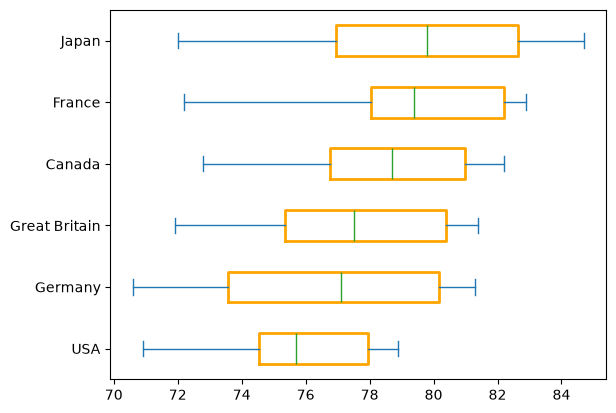

In [331]:
life_exp_wide[life_exp_wide.median().sort_values().index].plot.box(
    vert=False,
    boxprops={'linewidth': 2, 'color': 'orange'}
)
plt.show()

## Combining box plots and histograms

Because box plots are minimalist in their design &mdash; which contributes to their usefulness &mdash; they are often complmented with histograms, so that the shape of the distribution can be viewed as well.

Here is one way to combine them.

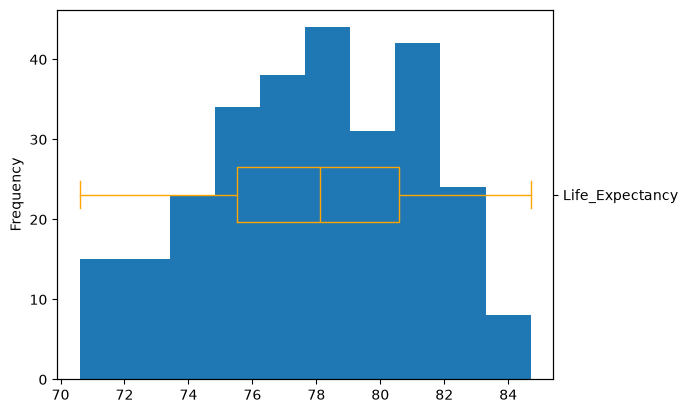

In [332]:
healthexp.Life_Expectancy.plot.hist()
plt.gca().twinx()
healthexp.Life_Expectancy.plot.box(vert=False, color='orange')
plt.show()

Another way is to juxtapose them vertically, using a horizontal box plot to match the x axis of the histogram.

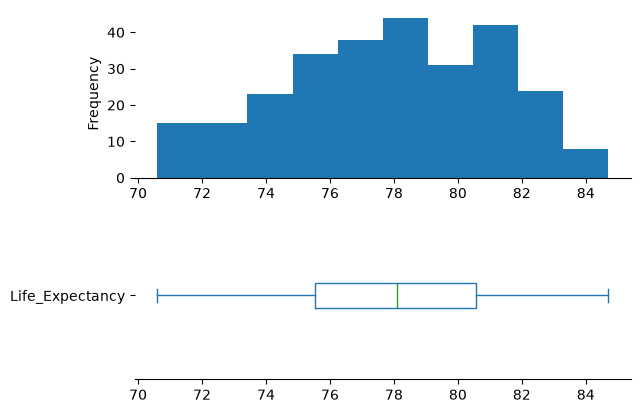

In [333]:
fig, ax = plt.subplots(2, 1)
healthexp.Life_Expectancy.plot.hist(ax=ax[0])
healthexp.Life_Expectancy.plot.box(ax=ax[1], vert=False)
sns.despine(left=True)
plt.show()

##  

## 